# Case study 3: Repuragent prioritises drugs to repurpose for Multiple Sulfatase Deficiency (MSD)

In this case study, Repruagent was required to prioritise a library of approximately 5K compounds for repurposing potential with an ultra-rare disease, MSD. This notebook focuses on analyzing the outputs generated by Repuragent. To see the agent full run please visit:
[https://repuragent.serve.scilifelab.se](https://repuragent.serve.scilifelab.se)


---

## Notebook Structure

This notebook includes four parts:
* **Part 1:** Confidence tier summary
* **Part 2:** Drug-Target association analysis

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Nature-style global settings
COLORS = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 15,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
sns.set_theme(style="ticks")


# Part 1: Confidence Tier summary

In [9]:
# Load data
df = pd.read_csv('repuragent_output/MSD_repurposing_screen_all.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rank                   5159 non-null   int64  
 1   compound_name          5159 non-null   str    
 2   chembl_id              5158 non-null   str    
 3   display_target         5159 non-null   bool   
 4   primary_target         3517 non-null   str    
 5   mechanism_category     5159 non-null   str    
 6   mechanistic_rationale  5159 non-null   str    
 7   supporting_evidence    5159 non-null   str    
 8   confidence_tier        5159 non-null   str    
 9   composite_score        5159 non-null   float64
 10  pchembl_value          3517 non-null   float64
 11  confidence_score       3517 non-null   float64
 12  max_phase              2941 non-null   float64
 13  full_mwt               5097 non-null   float64
 14  alogp                  5018 non-null   float64
 15  num_ro5_violati

/var/folders/y3/3m3209mn1sxcmgxls255b9f40000gn/T/ipykernel_70636/2212178454.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0, 1, 1])


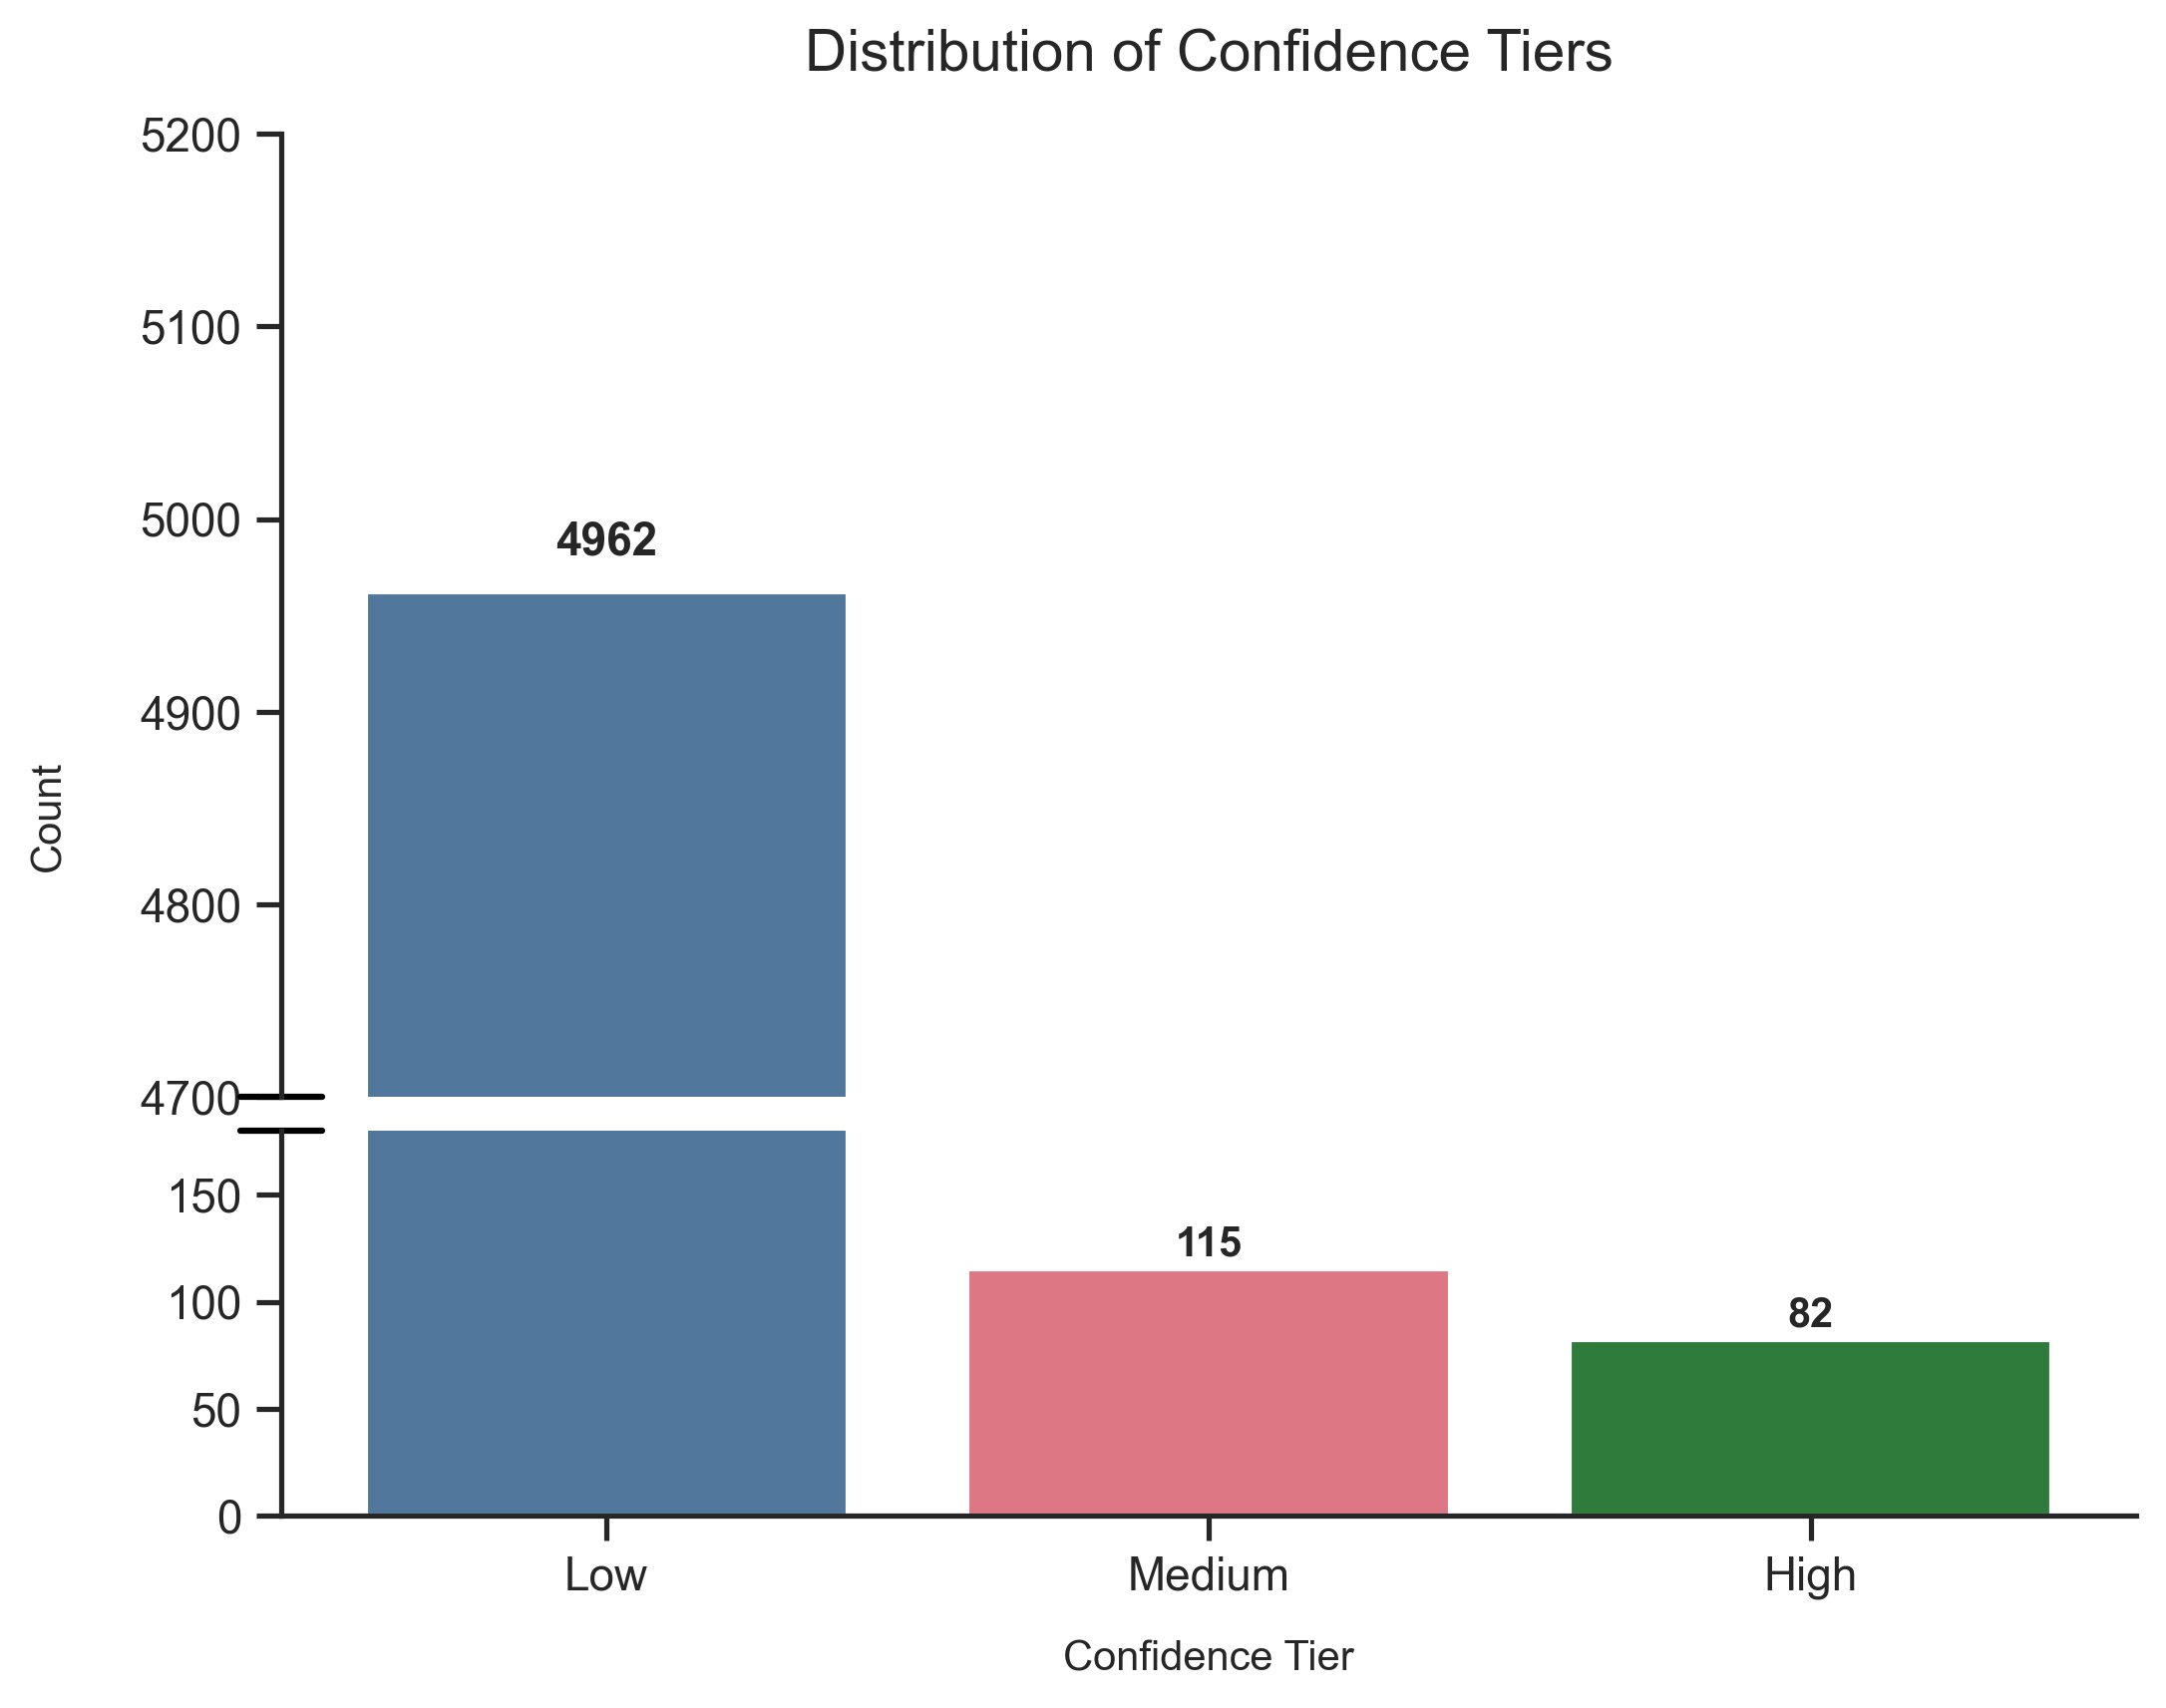

In [10]:
# Summary data 
count = pd.DataFrame(df['confidence_tier'].value_counts()).reset_index()


# Draw figure
palette = COLORS[:3]
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                                      gridspec_kw={'height_ratios': [2.5, 1], 'hspace': 0.05})

for ax in [ax_top, ax_bot]:
    sns.barplot(data=count, x='confidence_tier', y='count',
                hue='confidence_tier', palette=palette, legend=False, ax=ax)

# Set axis limits
ax_top.set_ylim(4700, 5200)
ax_bot.set_ylim(0, 180)

# Count labels — top panel (Low only)
for bar in ax_top.patches:
    height = bar.get_height()
    if height > 4700:
        ax_top.text(bar.get_x() + bar.get_width() / 2, height + 15,
                    f'{int(height)}', ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

# Count labels — bottom panel (Medium and High)
for bar in ax_bot.patches:
    height = bar.get_height()
    if 0 < height <= 180:
        ax_bot.text(bar.get_x() + bar.get_width() / 2, height + 3,
                    f'{int(height)}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

# Hide spines at the break
ax_top.spines['bottom'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_bot.spines['right'].set_visible(False)
ax_top.tick_params(bottom=False)

# Break marks — LEFT SIDE ONLY, horizontal slash style
kwargs_top = dict(transform=ax_top.transAxes, color='black', clip_on=False, lw=1.5)
ax_top.plot((-0.022, 0.022), (0, 0), **kwargs_top)  # bottom-left of top panel

kwargs_bot = dict(transform=ax_bot.transAxes, color='black', clip_on=False, lw=1.5)
ax_bot.plot((-0.022, 0.022), (1, 1), **kwargs_bot)   # top-left of bottom panel

# Axis labels
ax_bot.set_xlabel('Confidence Tier', fontsize=10, labelpad=10)
ax_top.set_title('Distribution of Confidence Tiers', fontsize=14, pad=15)
ax_top.set_ylabel('')
ax_bot.set_ylabel('')

fig.text(0.02, 0.5, 'Count', va='center', rotation='vertical', fontsize=10)

sns.despine(ax=ax_top, bottom=True, right=True)
sns.despine(ax=ax_bot, top=True, right=True)

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

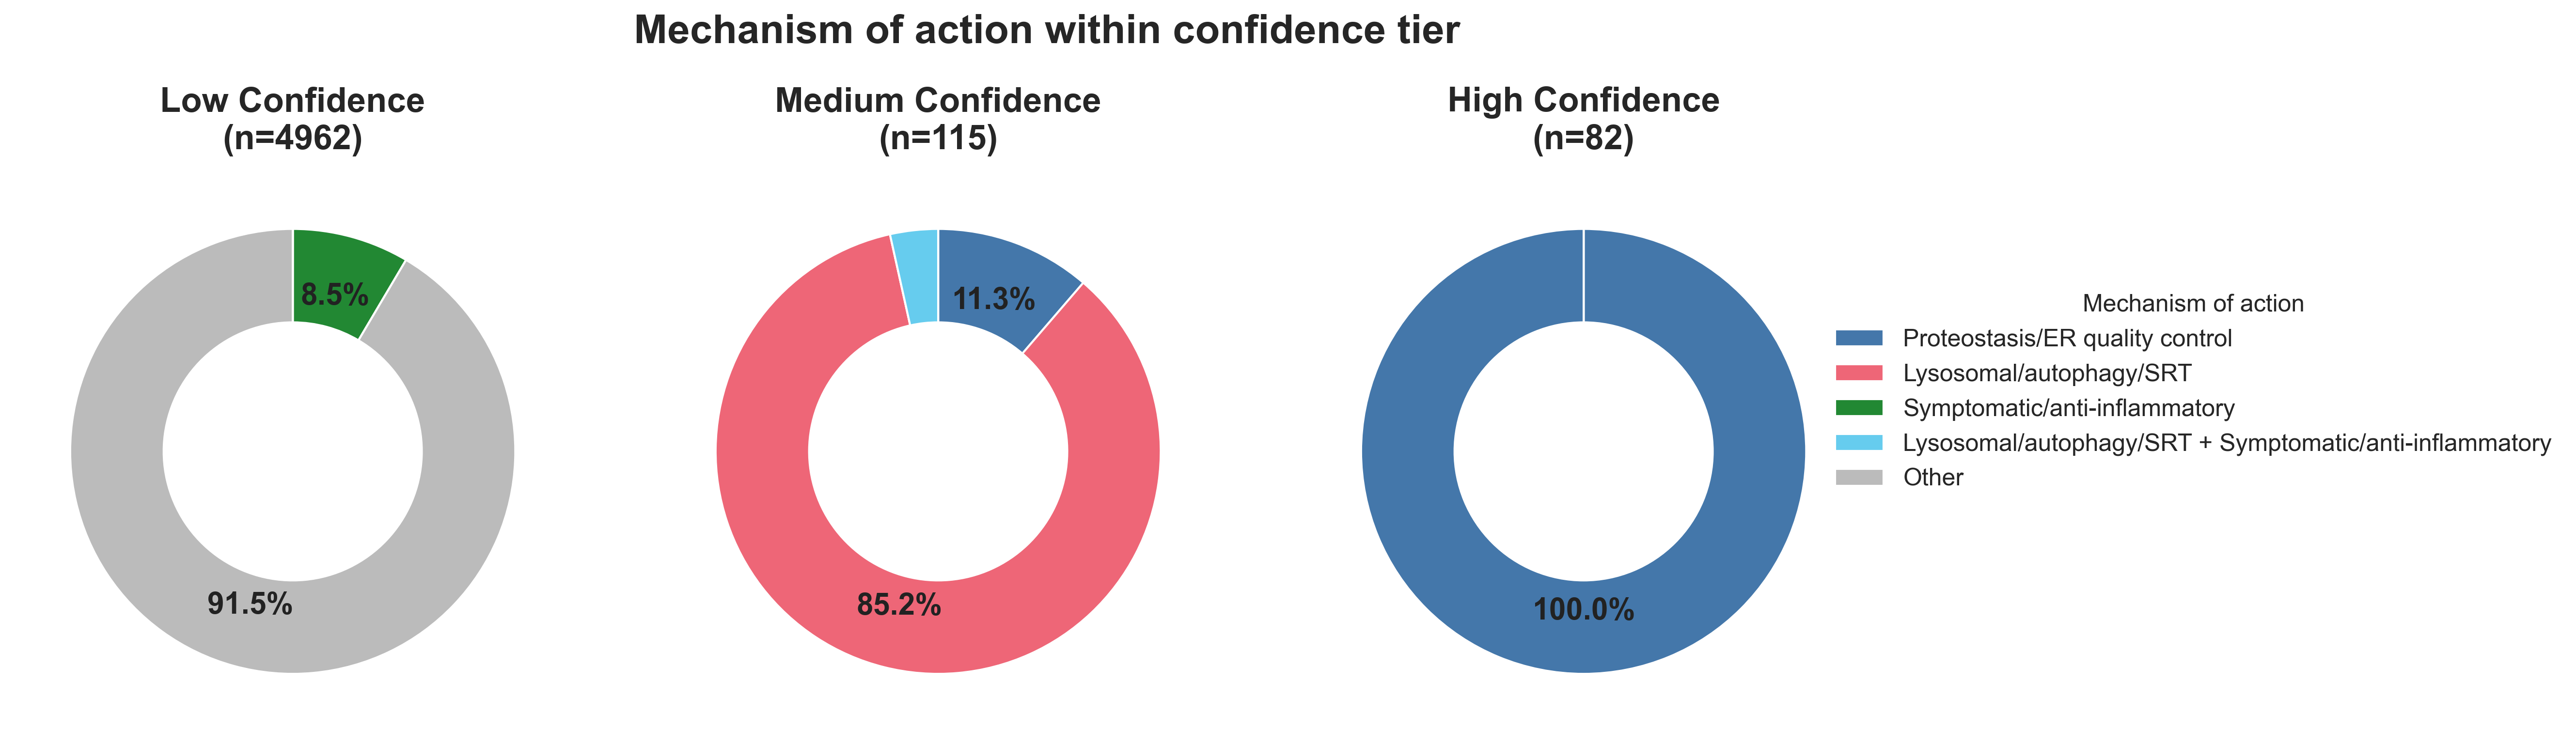

In [27]:
def classify_hit(row):
    "To lassify each row into one category"
    t1 = bool(row['tier1_hit'])
    t2 = bool(row['tier2_hit'])
    t3 = bool(row['tier3_hit'])

    if t1:
        return 'Proteostasis/ER quality control'
    elif t2 and t3:
        return 'Lysosomal/autophagy/SRT + Symptomatic/anti-inflammatory'
    elif t2:
        return 'Lysosomal/autophagy/SRT'
    elif t3:
        return 'Symptomatic/anti-inflammatory'
    else:
        return 'Other'

# Classify hits
df['hit_group'] = df.apply(classify_hit, axis=1)

# Plot
confidence_order = ['Low', 'Medium', 'High']
group_order = ['Proteostasis/ER quality control', 'Lysosomal/autophagy/SRT', 'Symptomatic/anti-inflammatory', 'Lysosomal/autophagy/SRT + Symptomatic/anti-inflammatory', 'Other']

colors = {
    'Proteostasis/ER quality control': '#4477AA',
    'Lysosomal/autophagy/SRT': '#EE6677',
    'Symptomatic/anti-inflammatory': '#228833',
    'Lysosomal/autophagy/SRT + Symptomatic/anti-inflammatory': '#66CCEE',
    'Other': '#BBBBBB'
}

# only annotate wedges above this %
label_threshold = 4

def autopct_threshold(values, threshold=1):
    total = sum(values)
    def _fmt(pct):
        count = int(round(pct * total / 100.0))
        if pct < threshold or count == 0:
            return ''
        return f'{pct:.1f}%'
    return _fmt

# Draw figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
legend_handles = None

for ax, conf in zip(axes, confidence_order):
    subset = df[df['confidence_tier'] == conf]
    counts = subset['hit_group'].value_counts().reindex(group_order, fill_value=0)

    wedges, _, autotexts = ax.pie(
        counts.values,
        labels=None,  # <- remove outer labels entirely
        colors=[colors[g] for g in group_order],
        startangle=90,
        counterclock=False,
        autopct=autopct_threshold(counts.values, threshold=label_threshold),
        pctdistance=0.72,
        wedgeprops=dict(width=0.42, edgecolor='white', linewidth=1)
    )

    if legend_handles is None:
        legend_handles = wedges

    ax.set_title(
        f'{conf} Confidence\n(n={counts.sum()})',
        fontsize=17,
        fontweight='bold',
        pad=12
    )
    ax.set_aspect('equal')

    for t in autotexts:
        t.set_fontsize(15)
        t.set_fontweight('bold')
        t.set_color('#222222')

fig.legend(
    legend_handles,
    group_order,
    title='Mechanism of action',
    loc='center right',
    bbox_to_anchor=(1.2, 0.5),
    frameon=False,
    fontsize=12,
    title_fontsize=12
)

plt.suptitle(
    'Mechanism of action within confidence tier',
    fontsize=20,
    fontweight='bold',
    y=1.02
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# Part 2:  Drug-Target association analysis 

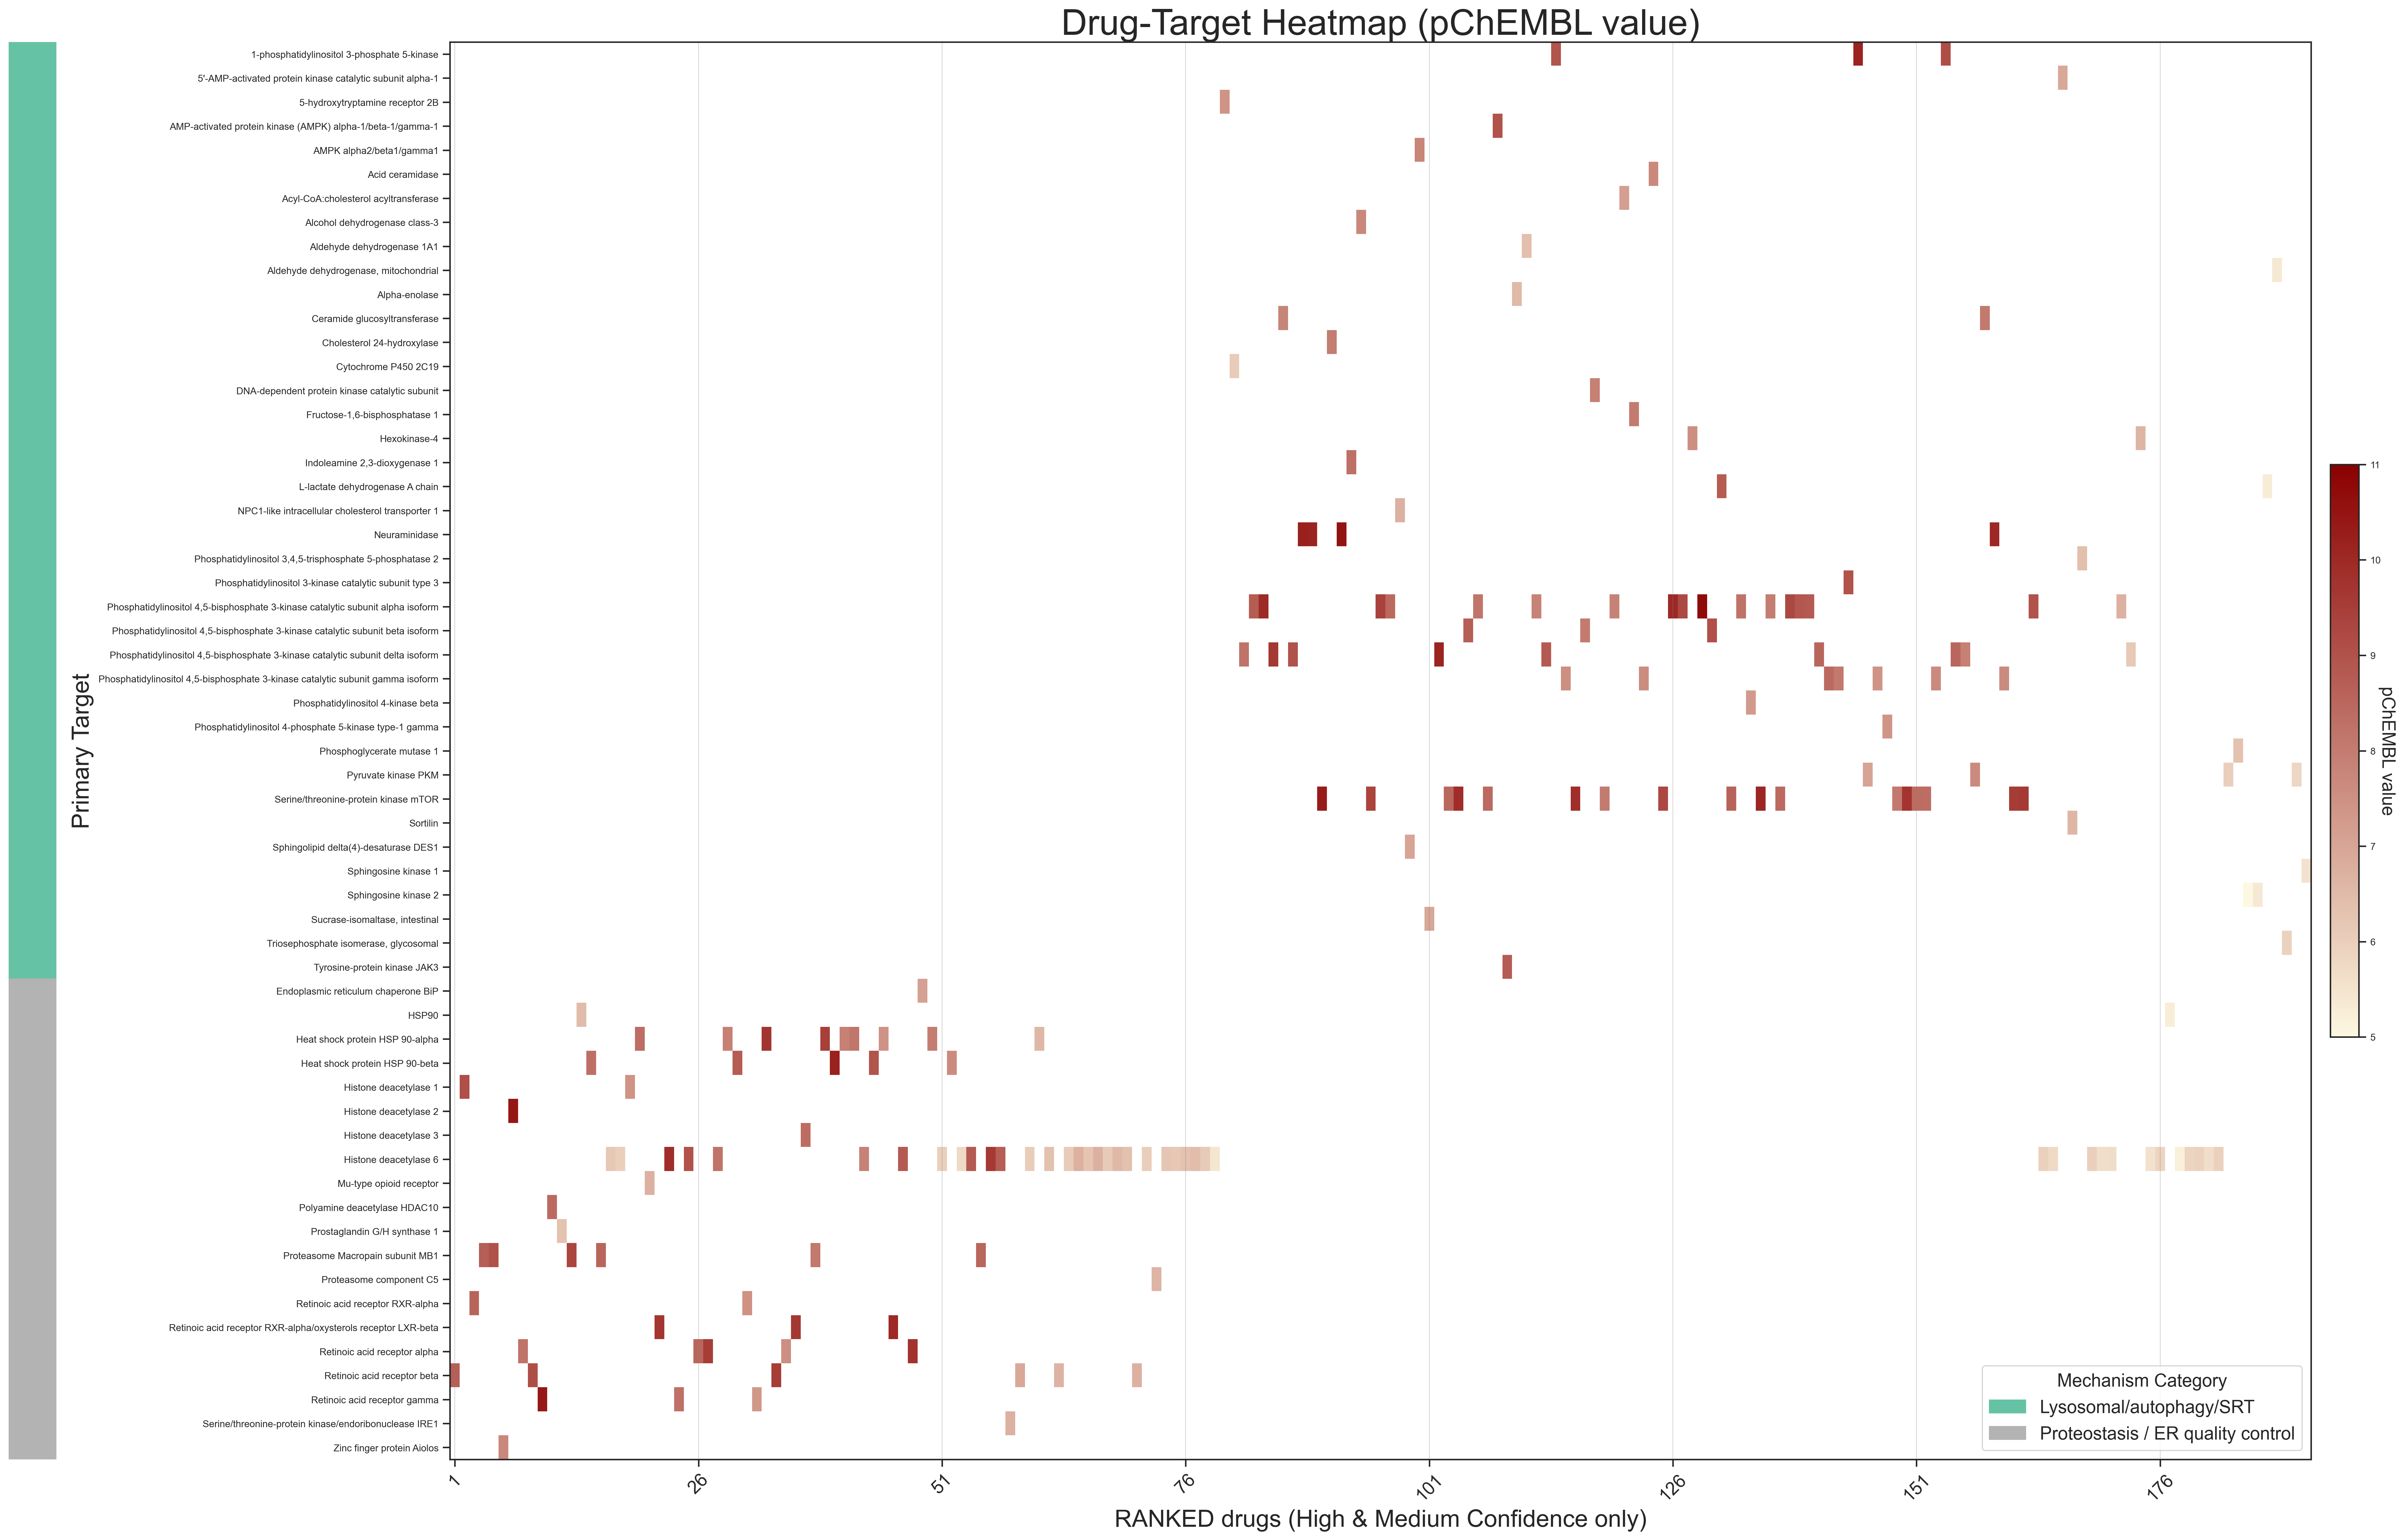

In [20]:
# Process data
df_hm = df[df['confidence_tier'].isin(['High', 'Medium'])].copy()
df_hm = df_hm.dropna(subset=['primary_target'])
df_hm = df_hm.sort_values('rank').reset_index(drop=True)
df_hm['plot_rank'] = np.arange(1, len(df_hm) + 1)

# pCHEML pivot
pivot = df_hm.pivot_table(index='primary_target', columns='plot_rank',
                          values='pchembl_value', aggfunc='mean')
pivot = pivot.reindex(columns=np.arange(1, len(df_hm) + 1))

# Map targets to categories
target_cat = (df_hm[['primary_target', 'mechanism_category']]
              .drop_duplicates()
              .set_index('primary_target')['mechanism_category']
              .fillna('Unknown'))
target_cat = target_cat[target_cat.index.isin(pivot.index)]

# Sort alphabetically within each category
cats = sorted(target_cat.unique())
ordered_targets = []
for cat in cats:
    members = sorted(target_cat[target_cat == cat].index.tolist())
    ordered_targets.extend(members)

pivot_ordered = pivot.loc[ordered_targets]

# Color for category
cat_colors = plt.cm.Set2(np.linspace(0, 1, len(cats)))
cat_color_map = {c: cat_colors[i] for i, c in enumerate(cats)}

# Plot
fig, (ax_cb, ax) = plt.subplots(1, 2, figsize=(28, 18),
                                gridspec_kw={'width_ratios': [0.025, 1]})

# Category color band
n = len(ordered_targets)
for i, t in enumerate(ordered_targets):
    ax_cb.add_patch(mpatches.Rectangle((0, n - i - 1), 1, 1,
                    color=cat_color_map[target_cat[t]]))
ax_cb.set_xlim(0, 1)
ax_cb.set_ylim(0, n)
ax_cb.axis('off')

# Main heatmap
cmap = LinearSegmentedColormap.from_list('cream_red', ['#fdf8e1', '#8b0000'])
im = ax.imshow(pivot_ordered.values, aspect='auto', cmap=cmap, vmin=5, vmax=11,
               interpolation='nearest')


ax.set_yticks(range(n))
ax.set_yticklabels(ordered_targets, fontsize=8)
ax.set_xlabel('RANKED drugs (High & Medium Confidence only)', fontsize=20)
ax.set_ylabel('Primary Target', fontsize=20)
ax.set_title('Drug-Target Heatmap (pChEMBL value)', fontsize=30)

xtick_positions = np.arange(0, pivot_ordered.shape[1], 25)
ax.set_xticks(xtick_positions)
ax.set_xticklabels([str(int(x) + 1) for x in xtick_positions], fontsize=15, rotation=45)
for x in xtick_positions:
    ax.axvline(x=x, color='grey', linewidth=0.4, alpha=0.5)

# Colourbar
cbar = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cbar.set_ticks([5, 6, 7, 8, 9, 10, 11])
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_ylabel('pChEMBL value', fontsize=15, rotation=270, labelpad=12)

# Legend
legend_patches = [mpatches.Patch(color=cat_color_map[c], label=c) for c in cats]
ax.legend(handles=legend_patches, loc='lower right', fontsize=15,
          title='Mechanism Category', title_fontsize=15, framealpha=0.8)

plt.tight_layout()
plt.show()